# Основы глубинного обучения, майнор ИАД

## Домашнее задание 1: полносвязные сети



## Оценивание и штрафы

Максимально допустимая оценка за работу — 10 баллов. Сдавать задание после указанного срока сдачи нельзя.

Задание выполняется самостоятельно. «Похожие» решения считаются плагиатом и все задействованные студенты (в том числе те, у кого списали) не могут получить за него больше 0 баллов. Если вы нашли решение какого-то из заданий (или его часть) в открытом источнике, необходимо указать ссылку на этот источник в отдельном блоке в конце вашей работы (скорее всего вы будете не единственным, кто это нашел, поэтому чтобы исключить подозрение в плагиате, необходима ссылка на источник).  Если два студента сгенерировали в нейронке одинаковые либо похожие решения, это считается плагиатом и приводит к обнулению обеих работ.

Неэффективная реализация кода может негативно отразиться на оценке. Также оценка может быть снижена за плохо читаемый код и плохо оформленные графики. Все ответы должны сопровождаться кодом или комментариями о том, как они были получены.

Итогова оценка считается как

$$
min(part_1, part_2) \cdot 0.6 + max(part_1, part_2) \cdot 0.2 + part_3 \cdot 0.2
$$

где $part_1$, $part_2$ и $part_3$ - оценки за первую, вторую и третью части работы

> Также, за домашнее задание выставляется 0, если не сделано нулевое задание либо нет подробного описания ваших экспериментов в третьей части.

## Оформление

1. Обязательно фиксируйте зерно генератора случайных чисел в экспериментах. При перезапуске кода значения не должны меняться.
2. Вверху файла подпишите фамилию, имя и какой-то занимательный факт о себе.
3. Обратите внимание, что у графиков должны быть подписаны оси, заголовок графика и при необходимости обязательно наличие легенды.

> За отсутствие названий графиков и подписей к осям могут снижаться баллы. Все картинки должны быть самодостаточны и визуально удобны для восприятия, так чтобы не нужно было смотреть ваш код или знать задание, чтобы понять что на них изображено.

Из каждого проведённого эксперимента делайте выводы и фиксируйте их. Эти выводы не должны быть поверхностными и очевидными. Не будьте мудрым королём.

<br>

<center>
<img src="https://raw.githubusercontent.com/hse-ds/iad-deep-learning/refs/heads/master/2025/homeworks/king.png" width="300">
</center>

**Пример плохого вывода:** Синенькая линия идет вверх, а красная вниз. Черненькая идет вниз, а потом вверх.

<br>

<center>
<img src="https://raw.githubusercontent.com/hse-ds/iad-deep-learning/refs/heads/master/2025/homeworks/bad_lines.png" width="600">
</center>

## О задании

Вам предстоит обучить полносвязную нейронную сеть для предсказания года выпуска песни по ее аудио-признакам. Для этого мы будем использовать [Million Songs Dataset](https://samyzaf.com/ML/song_year/song_year.html).

In [5]:
import torch
from torch import nn
import torch.nn.functional as F

import pandas as pd
import numpy as np
import random

from tqdm.notebook import tqdm
from IPython.display import clear_output
import matplotlib.pyplot as plt

device = "cuda" if torch.cuda.is_available() else "cpu"

Начнем с того, что скачаем и загрузим данные:

In [ ]:
# !wget -O yearpredictionmsd.zip https://archive.ics.uci.edu/static/public/203/yearpredictionmsd.zip

--2025-10-09 18:37:22--  https://archive.ics.uci.edu/static/public/203/yearpredictionmsd.zip
Resolving archive.ics.uci.edu (archive.ics.uci.edu)... 128.195.10.252
Connecting to archive.ics.uci.edu (archive.ics.uci.edu)|128.195.10.252|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: unspecified
Saving to: ‘yearpredictionmsd.zip’

yearpredictionmsd.z     [  <=>               ] 201.24M  8.87MB/s    in 13s     

2025-10-09 18:37:36 (15.0 MB/s) - ‘yearpredictionmsd.zip’ saved [211011981]



In [6]:
df = pd.read_csv('../yearpredictionmsd.zip', header=None)
df.head()

,0,1,2,3,4,5,6,7,8,9,...,81,82,83,84,85,86,87,88,89,90
0,2001,49.94357,21.47114,73.07750,8.74861,-17.40628,-13.09905,-25.01202,-12.23257,7.83089,...,13.01620,-54.40548,58.99367,15.37344,1.11144,-23.08793,68.40795,-1.82223,-27.46348,2.26327
1,2001,48.73215,18.42930,70.32679,12.94636,-10.32437,-24.83777,8.76630,-0.92019,18.76548,...,5.66812,-19.68073,33.04964,42.87836,-9.90378,-32.22788,70.49388,12.04941,58.43453,26.92061
2,2001,50.95714,31.85602,55.81851,13.41693,-6.57898,-18.54940,-3.27872,-2.35035,16.07017,...,3.03800,26.05866,-50.92779,10.93792,-0.07568,43.20130,-115.00698,-0.05859,39.67068,-0.66345
3,2001,48.24750,-1.89837,36.29772,2.58776,0.97170,-26.21683,5.05097,-10.34124,3.55005,...,34.57337,-171.70734,-16.96705,-46.67617,-12.51516,82.58061,-72.08993,9.90558,199.62971,18.85382
4,2001,50.97020,42.20998,67.09964,8.46791,-15.85279,-16.81409,-12.48207,-9.37636,12.63699,...,9.92661,-55.95724,64.92712,-17.72522,-1.49237,-7.50035,51.76631,7.88713,55.66926,28.74903


Посмотрим на статистики по данным.

In [7]:
df.describe()

,0,1,2,3,4,5,6,7,8,9,...,81,82,83,84,85,86,87,88,89,90
count,515345.000000,515345.000000,515345.000000,515345.000000,515345.000000,515345.000000,515345.000000,515345.000000,515345.000000,515345.000000,...,515345.000000,515345.000000,515345.000000,515345.000000,515345.000000,515345.000000,515345.000000,515345.000000,515345.000000,515345.000000
mean,1998.397082,43.387126,1.289554,8.658347,1.164124,-6.553601,-9.521975,-2.391089,-1.793236,3.727876,...,15.755406,-73.461500,41.542422,37.934119,0.315751,17.669213,-26.315336,4.458641,20.035136,1.329105
std,10.931046,6.067558,51.580351,35.268585,16.322790,22.860785,12.857751,14.571873,7.963827,10.582861,...,32.099635,175.618889,122.228799,95.050631,16.161764,114.427905,173.977336,13.346557,185.558247,22.088576
min,1922.000000,1.749000,-337.092500,-301.005060,-154.183580,-181.953370,-81.794290,-188.214000,-72.503850,-126.479040,...,-437.722030,-4402.376440,-1810.689190,-3098.350310,-341.789120,-3168.924570,-4319.992320,-236.039260,-7458.378150,-381.424430
25%,1994.000000,39.954690,-26.059520,-11.462710,-8.487500,-20.666450,-18.440990,-10.780600,-6.468420,-2.293660,...,-1.812650,-139.555160,-20.986900,-4.669540,-6.781590,-31.580610,-101.530300,-2.566090,-59.509270,-8.820210
50%,2002.000000,44.258500,8.417850,10.476320,-0.652840,-6.007770,-11.188390,-2.046670,-1.736450,3.822310,...,9.171850,-53.090060,28.791060,33.623630,0.820840,15.598470,-21.204120,3.117640,7.759730,0.053050
75%,2006.000000,47.833890,36.124010,29.764820,8.787540,7.741870,-2.388960,6.508580,2.913450,9.961820,...,26.274480,13.478730,89.661770,77.785800,8.470990,67.794960,52.389330,9.967740,86.351610,9.679520
max,2011.000000,61.970140,384.065730,322.851430,335.771820,262.068870,166.236890,172.402680,126.741270,146.297950,...,840.973380,4469.454870,3210.701700,1734.079690,260.544900,3662.065650,2833.608950,463.419500,7393.398440,677.899630


Целевая переменная, год выпуска песни, записана в первом столбце. Посмотрим на ее распределение.

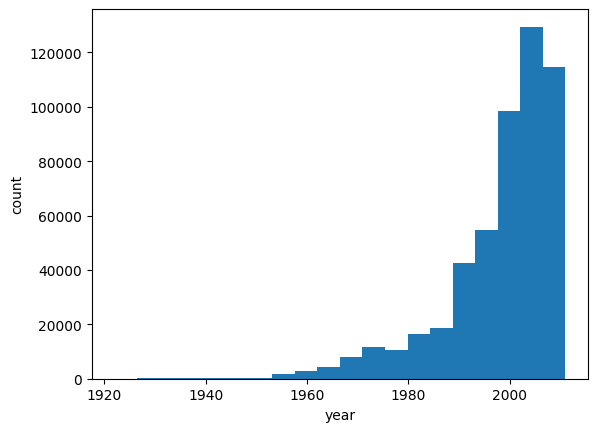

Range: 1922 - 2011
Unique values: 89


In [8]:
plt.hist(df.iloc[:, 0], bins=20)
plt.xlabel('year')
plt.ylabel('count')
plt.show()
print(f'Range: {df.iloc[:, 0].min()} - {df.iloc[:, 0].max()}')
print(f'Unique values: {np.unique(df.iloc[:, 0]).size}')

Разобьем данные на обучение и тест (не меняйте здесь ничего, чтобы сплит был одинаковым у всех).

In [9]:
X = df.iloc[:, 1:].values
y = df.iloc[:, 0].values

train_size = int(0.75 * X.shape[0])

X_train = X[:train_size, :]
y_train = y[:train_size]
X_test = X[train_size:, :]
y_test = y[train_size:]

X_train.shape, X_test.shape

((386508, 90), (128837, 90))

## Полезные советы:

- Если вы сразу реализуете обучение на GPU, то у вас будет больше времени на эксперименты, так как любые вычисления будут работать быстрее. Google Colab предоставляет несколько GPU-часов (обычно около 8-10) в сутки бесплатно.

- Если вы чего-то не знаете, не стесняйтесь гуглить. В интернете очень много полезной информации, туториалов и советов по глубинному обучению и `pytorch`. Но не забывайте, что за списанный код без ссылки на источник последует наказание.

- Чтобы отладить код, можете обучаться на небольшой части данных или даже на одном батче. Если лосс на обучающей выборке не падает, то что-то точно идет не так.

- Пользуйтесь утилитами, которые вам предоставляет `pytorch` (например, `Dataset` и `Dataloader`). Их специально разработали для упрощения разработки пайплайна обучения.

- Скорее всего, вы захотите отслеживать прогресс обучения. Для создания прогресс-баров есть удобная библиотека `tqdm`.

- Быть может, вы захотите, чтобы графики рисовались прямо во время обучения. Можете воспользоваться функцией [clear_output](http://ipython.org/ipython-doc/dev/api/generated/IPython.display.html#IPython.display.clear_output), чтобы удалять старый график и рисовать новый на его месте.

- При желании вы можете логгировать метрики обучения и свои эксперименты в WandB либо любой другой сервис. Не забудьте приложить к тетрадке ссылку на результаты экспериментов либо скришноты графиков с пояснениями, что проверяющий должен на них увидеть.

- Финальное значение тестовой метрики для удобства проверки выведите в тетрадке.

## Задание 0 (0 баллов, но при невыполнении максимальная оценка за всю работу &mdash; 0 баллов)

Мы будем использовать RMSE как метрику качества. Прежде чем обучать нейронные сети, нам нужно проверить несколько простых бейзлайнов, чтобы было с чем сравнить более сложные алгоритмы. Для этого бучите `Ridge` регрессию из `sklearn`. Кроме того, посчитайте качество при наилучшем константном прогнозе.

Для выполнения данного задания (и всех последующих) предобработайте данные.

1. Зафиксируйте random_seed везде где только возможно. Вам предоставлена функция для этого, однако вы можете дополнить ее своими дополнениями.
2. Обучите `StandertScaler` и предобработайте ваши данные. В следующих заданиях можете использовать другой `scaler` или вообще отказаться от него.


In [10]:
def set_global_seed(seed: int) -> None:
    """Set global seed for reproducibility.
    :param int seed: Seed to be set
    """
    torch.backends.cudnn.deterministic = True
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    np.random.seed(seed)
    random.seed(seed)

    # также можно зафиксировать seed для Dataloader
    g = torch.Generator()
    g.manual_seed(seed)
    return g

# Сид для каждого worker в Dataloader
def seed_worker(worker_id):
    worker_seed = torch.initial_seed() % 2**32
    np.random.seed(worker_seed)
    random.seed(worker_seed)

g = set_global_seed(42)

In [11]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [12]:
np.logspace(-5, 5, 10)

array([1.00000000e-05, 1.29154967e-04, 1.66810054e-03, 2.15443469e-02,
       2.78255940e-01, 3.59381366e+00, 4.64158883e+01, 5.99484250e+02,
       7.74263683e+03, 1.00000000e+05])

In [13]:
from sklearn.linear_model import Ridge
from sklearn.metrics import root_mean_squared_error 
from sklearn.model_selection import cross_val_score

alphas = np.logspace(-5, 5, 10)
best_alpha = None
best_score = np.inf

for alpha in alphas:
    scores = cross_val_score(Ridge(alpha=alpha), X=X_train_scaled, y=y_train, cv=5, scoring='neg_root_mean_squared_error')
    if -scores.mean() < best_score:
        best_score = -scores.mean()
        best_alpha = alpha

print(f'Best RMSE = {best_score}, best alpha = {best_alpha}')


Best RMSE = 9.584379886116086, best alpha = 599.4842503189421


In [14]:
# смотрим на результаты на train и test с найденным лучшим гиперпараметром
model = Ridge(alpha=best_alpha)
model.fit(X_train_scaled, y_train)
y_pred_train = model.predict(X_train_scaled)
y_pred_test = model.predict(X_test_scaled)
rmse_train = root_mean_squared_error(y_train, y_pred_train)
rmse_test = root_mean_squared_error(y_test, y_pred_test)
print(f'RMSE на train: {rmse_train:.4f}')
print(f'RMSE на test: {rmse_test:.4f}')

RMSE на train: 9.5742
RMSE на test: 9.4739


Лучшая константа для RMSE это среднее. Используйте среднее, расчитанное на трэйне в качестве прогноза для теста и посчитайте для такой наивной модели RMSE.

In [15]:
mean_prediction = y_train.mean()
best_rmse_train = root_mean_squared_error(y_train, np.ones(y_train.shape[0])*mean_prediction)
best_rmse_test = root_mean_squared_error(y_test, np.ones(y_test.shape[0])*mean_prediction)
print(f'Best RMSE на train: {best_rmse_train:.4f}')
print(f'Best RMSE на test: {best_rmse_test:.4f}')

Best RMSE на train: 10.9594
Best RMSE на test: 10.8455


Видно, что линейная модель не сильно лучше справляется, чем константное предсказание, оба ошибаются на лет 10. Это не очень, так как диапазон у нас всего ~ 100 лет. Видимо линейные модели не достаточно сложны, чтобы решить эту задачу.

Теперь приступим к экспериментам с нейросетями. Для начала отделим от данных валидацию. Тестовую выборку мы будем использовать только для того, чтобы измерить итоговую метрику качества модели.

In [16]:
from sklearn.model_selection import train_test_split
# тут сделаем два набора - один отстандартизированный, другой - нет
X_train_scaled, X_val_scaled, y_train_scaled, y_val_scaled = train_test_split(X_train_scaled, y_train, test_size=0.25, random_state=0xE2E4)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.25, random_state=0xE2E4)

## Часть I. Обучаем линейную регрессию (максимум 10 баллов)

**Задание 1 (10 баллов):** Обучите в `pytorch` линейную регрессию.

- Создайте модель линейной регрессии, которая будет состоять только из одного `Linear()` слоя.
   
- Напишите цикл обучения вашей линейной регрессии. В нем реализуйте подсчет функции потерь, сделайте шаг градиентного спуска. Запрещено использовать готовые оптимизаторы и loss-функции из библиотеки `pytorch`. Для подсчета градиента воспользуйтесь методом backward.
   
- Запустите обучение на 10 эпохах, после каждой проверяйте значение целевой метрики на тестовой выборке.
   
- Выведите на экран графики метрики и значения функции потерь на тестовой и обучающей выборке.

В данном задании нет цели побить какой-то порог по метрике. Ваша задача &mdash; убедиться в том, что ваш рукописный цикл обучения работает. Для ускорения вычислений и обучения модели можете брать только срез данных, а не весь датасет.

In [17]:
from torch import nn

In [18]:
X_train.shape

(289881, 90)

In [19]:
'''наша нейронная сеть состоит из всего одного слоя
на вход в слой будет поступать 90 признкаов, а выходить будет один, так как у на выходе нам нужен один год'''
lin_reg_nn = nn.Linear(X_train_scaled.shape[1], 1)

# зададим функцию ошибки
def mse_loss(y_true: torch.Tensor, y_pred: torch.Tensor) -> torch.Tensor:
  return torch.mean((y_true - y_pred)**2)

In [20]:
# возьмем функции для построения графиков из первого семинаров, немного изменим под нашу задачу
import seaborn as sns
sns.set_style('whitegrid')
plt.rcParams.update({'font.size': 15})

def plot_losses(train_losses, test_losses, train_rmse, test_rmse):
    clear_output()
    fig, axs = plt.subplots(1, 2, figsize=(15, 4))
    axs[0].plot(range(1, len(train_losses) + 1), train_losses, label='train')
    axs[0].plot(range(1, len(test_losses) + 1), test_losses, label='test')
    axs[0].set_ylabel('loss')

    axs[1].plot(range(1, len(train_rmse) + 1), train_rmse, label='train')
    axs[1].plot(range(1, len(test_rmse) + 1), test_rmse, label='test')
    axs[1].set_ylabel('rmse')

    for ax in axs:
        ax.set_xlabel('epoch')
        ax.legend()

    plt.show()

In [21]:
# перейдем от numpy array к tensor во всех массивах с нашими данными
# также поменяем тип на torch.float32, чтобы он был такой же как и у нейросети
X_train_scaled = torch.tensor(X_train_scaled, dtype=torch.float32)
X_val_scaled = torch.tensor(X_val_scaled, dtype=torch.float32)
X_test_scaled = torch.tensor(X_test_scaled, dtype=torch.float32)
y_train_scaled = torch.tensor(y_train_scaled, dtype=torch.float32)
y_val_scaled = torch.tensor(y_val_scaled, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.float32)

In [22]:
lin_reg_nn.to(device) # перенесем нейросеть на device

Linear(in_features=90, out_features=1, bias=True)

In [23]:
# создадим датасеты и их соответсвующие лоадеры с батчем 64 для дальнейшего обучения нашей нейросети
from torch.utils.data import DataLoader, TensorDataset
train_dataset_scaled = TensorDataset(X_train_scaled, y_train_scaled)
train_loader_scaled = DataLoader(train_dataset_scaled, batch_size=64, shuffle=True)
val_dataset_scaled = TensorDataset(X_val_scaled, y_val_scaled)
val_loader_scaled = DataLoader(val_dataset_scaled, batch_size=64, shuffle=False)
test_dataset_scaled = TensorDataset(X_test_scaled, y_test)
test_loader_scaled = DataLoader(test_dataset_scaled, batch_size=64, shuffle=False)

In [16]:
# !pip install wandb -qU

In [28]:
# будем использвать wandb для логирования результатов обучения нейросетей
wandb, wandb_project = None, None
# wandb_project = 'dl-iad-hw-1'
# import wandb
# wandb.login()

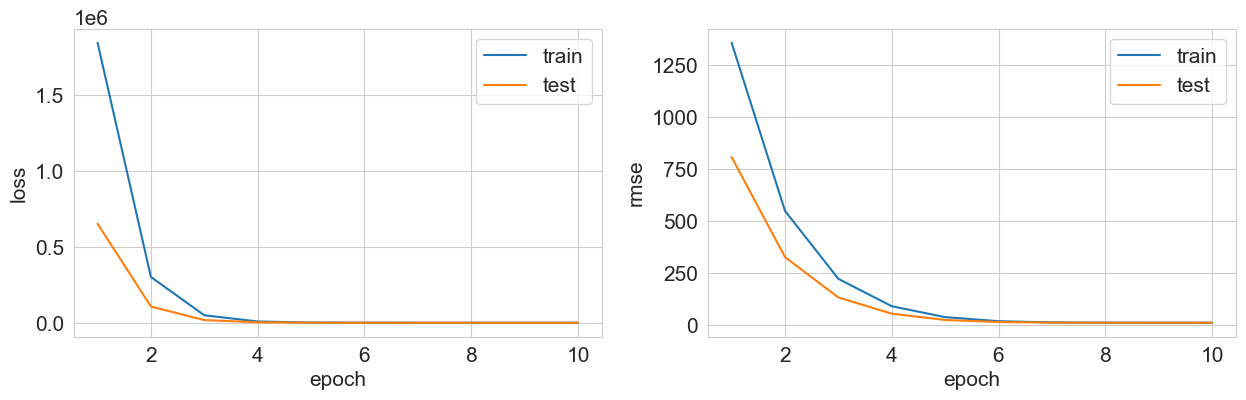

Epoch: 9, loss: 121.03204961130844, rmse: 11.001456704060079


In [29]:
# зададим эпоху и длину шага
epochs = 10
lr = 0.0001

# создадим списки для метрик
train_losses = []
val_losses = []
train_rmses = []
val_rmses = []

if wandb and wandb_project:
  # подключаем wandb
  wandb.init(
      project='dl-iad-hw-1',
      name='linreg via pytorch',
      config={
          'architecture': 'only linear layer',
          'learning_rate': lr,
          'scheduler': 'None',
          'epochs': epochs,
          'optimizer': 'handmade sgd'
      }
  )
  wandb.watch(lin_reg_nn)

for i in range(epochs):
  lin_reg_nn.train() # переключаем в train mode нашу нейросеть
  train_loss = 0
  for X_batch, y_batch in tqdm(train_loader_scaled, desc=f'Training {i}/{epochs}'):
    # идем по батчам, сначала переносим на device наши данные
    X_batch = X_batch.to(device)
    y_batch = y_batch.to(device)

    lin_reg_nn.zero_grad() # обнулим градиенты, иначе они будут накапливаться

    y_pred = lin_reg_nn(X_batch) # получим предсказания
    loss = mse_loss(y_batch, y_pred) # посчитаем ошибку

    loss.backward() # посчитаем градиенты

    # обновим веса в слое
    with torch.no_grad():
      lin_reg_nn.weight -= lr * lin_reg_nn.weight.grad
      lin_reg_nn.bias -= lr * lin_reg_nn.bias.grad

    train_loss += loss.item() * y_batch.shape[0] # будем копить ошибку по батчам
    if wandb_project:
      metrics = {
            "batch-train/loss": loss.item(),
      }
      wandb.log(metrics) # запишем метрики в wandb

  # теперь посчитаем наши метрики и построим графики
  # перед этим переведем модель в evaluation mode
  lin_reg_nn.eval()
  with torch.no_grad(): # не будем строить вычислительный граф, так как производные нам не нужны
    train_loss /= len(train_dataset_scaled) # накапливали ошибку по батчам тепреь надо поделить на длину датасета
    train_losses.append(train_loss)
    train_rmses.append(train_loss ** 0.5) # для получения rmse просто берем корень

    val_loss = 0
    for X_batch, y_batch in tqdm(val_loader_scaled, desc=f'Validating {i}/{epochs}'):
      # идем по батчам, сначала переносим на device наши данные
      X_batch = X_batch.to(device)
      y_batch = y_batch.to(device)

      y_pred = lin_reg_nn(X_batch) # получим предсказания
      loss = mse_loss(y_batch, y_pred) # посчитаем ошибку

      val_loss += loss.item() * y_batch.shape[0] # так же как и раньше накапливаем ошибку по батчам

    val_loss /= len(val_dataset_scaled) # накапливали ошибку по батчам тепреь надо поделить на длину датасета

    val_losses.append(val_loss)
    val_rmses.append(val_loss ** 0.5) # для получения rmse просто берем корень

    if wandb_project:
      metrics = {
          "train/loss": train_loss,
          "train/rmse": train_rmses[-1],
          "val/loss": val_loss,
          "val/rmse": val_rmses[-1]
      }
      wandb.log(metrics) # запишем метрики в wandb

    plot_losses(train_losses, val_losses, train_rmses, val_rmses) # построим графики ошибок на каждой итерации
    print(f"Epoch: {i}, loss: {val_losses[-1]}, rmse: {val_rmses[-1]}")

In [30]:
# теперь посчитаем метрики на тесте
lin_reg_nn.eval()
with torch.no_grad():
  test_loss = 0
  for X_batch, y_batch in test_loader_scaled:
    # идем по батчам, сначала переносим на device наши данные
    X_batch = X_batch.to(device)
    y_batch = y_batch.to(device)

    y_pred = lin_reg_nn(X_batch) # получим предсказания
    loss = mse_loss(y_batch, y_pred) # посчитаем ошибку

    test_loss += loss.item() * y_batch.shape[0] # накапливаем ошибку по батчам

  test_loss /= len(test_dataset_scaled) # накапливали ошибку по батчам, тепреь надо поделить на длину датасета
  test_loss = np.sqrt(test_loss) # для получения rmse просто берем корень

print(f'rmse on test: {test_loss}')

rmse on test: 10.839688026688885


По сути мы обучали линейную регрессию, только без регуляризации, поэтому и получили чуть худшие результаты, чем в Ridge. Результат плохой, так как находится на уровне предсказания константой. Ну и 10 лет в таком диапозоне не мало с учетом того, что большинство данных находятся в одном диапазоне.

In [31]:
# удалим ненужные переменные
del lin_reg_nn, train_dataset_scaled, train_loader_scaled, val_dataset_scaled, val_loader_scaled, test_dataset_scaled, test_loader_scaled, X_train_scaled, X_val_scaled, y_train_scaled, y_val_scaled

## Часть II. Заводим нейронную сеть (максимум 10 баллов)

Ниже нам предстоит реализовать довольно много различных нейросетей и поставить целую серию экспериментов. Чтобы это всё происходило без боли и страданий, нам нужно держать код в удобном виде.

При решении заданий вы можете придерживаться любой адекватной струкуры кода, но мы советуем воспользоваться сигнатурами функций, которые приведены ниже. При необходимости вы можете добавить в них любые нужные вам аргументы и любой нужный функционал. Более того, хорошей практикой является не делать эти функции слишком громоздкими и выносить разные хитрые штуки в отдельные функции.

In [32]:
@torch.no_grad()
def rmse(y_pred, y_true):
    """ Root mean squred error for computing metric on predicts
    params:
        y_pred - predictions
        y_true - true answers
    """

    return torch.sqrt(torch.mean((y_pred - y_true) ** 2))

def compute_ss(y_pred, y_true, encoder):
    """Computing SS (sum of squares) transforming prediction to years
    params:
        y_pred - prediction as classes
        y_true - true answers in classes
        encoder - encoder for converting years to classes
    """

    y_pred_years = encoder.inverse_transform(y_pred.cpu().numpy()).astype(np.float32)
    y_true_years = encoder.inverse_transform(y_true.cpu().numpy()).astype(np.float32)

    ss = ((y_pred_years - y_true_years) ** 2).sum()
    return ss

def training_epoch(model, optimizer, criterion, train_loader, encoder=None, tqdm_desc=None, wandb_project=None):
    """Одна эпоха обучения
    params:
        model - torch.nn.Module to be fitted
        optimizer - model optimizer
        criterion - loss function from torch.nn
        train_loader - torch.utils.data.Dataloader with train set
        encoder - encoder for converting years to classes. If None, model will be trained on mse, solving regression task.
        tqdm_desc - message for tqdm
        wand_project - name of project in wandb (if None - there will be no wandb project)
    """

    train_loss, train_ss = 0.0, 0.0
    model.train()
    for X_batch, y_batch in tqdm(train_loader, desc=tqdm_desc):
      X_batch = X_batch.to(device)
      y_batch = y_batch.to(device)

      optimizer.zero_grad()
      logits = model(X_batch)
      loss = criterion(logits, y_batch)
      loss.backward()
      optimizer.step()

      train_loss += loss.item() * y_batch.shape[0]
      if encoder:
        train_ss += compute_ss(torch.argmax(logits.detach(), dim=1), y_batch.detach(), encoder)

      if wandb_project and wandb:
        metrics = {
            "batch-train/loss": loss.item(),
        }
        wandb.log(metrics)

    train_loss /= len(train_loader.dataset)
    if encoder:
      train_rmse = np.sqrt(train_ss / len(train_loader.dataset))
    else:
      train_rmse = train_loss ** 0.5

    return train_loss, train_rmse

@torch.no_grad()
def validation_epoch(model, criterion, val_loader, encoder=None, tqdm_desc=None):
    """Одна эпоха валидации модели
    params:
        model - torch.nn.Module to be fitted
        criterion - loss function from torch.nn
        val_loader - torch.utils.data.Dataloader with test set
                      (if you wish to validate during training)
        encoder - encoder for converting years to classes. If None, model will be trained on mse, solving regression task.
        tqdm_desc - message for tqdm
    """

    val_loss, val_ss = 0.0, 0.0
    model.eval()
    for X_batch, y_batch in tqdm(val_loader, desc=tqdm_desc):
      X_batch = X_batch.to(device)
      y_batch = y_batch.to(device)

      logits = model(X_batch)
      loss = criterion(logits, y_batch)

      val_loss += loss.item() * y_batch.shape[0]
      if encoder:
        val_ss += compute_ss(torch.argmax(logits, dim=1), y_batch, encoder)

    val_loss /= len(val_loader.dataset)
    if encoder:
      val_rmse = np.sqrt(val_ss / len(val_loader.dataset))
    else:
      val_rmse = val_loss ** 0.5

    return val_loss, val_rmse

@torch.no_grad()
def predict(model, data_loader, task='regression', encoder=None):
    """ Предсказания модели (предсказывает классы)
    params:
        model - torch.nn.Module to be evaluated on test set
        data_loader - torch.utils.data.Dataloader with test set
        task - 'classification' or 'regression'
        encoder - encoder for converting years to classes. If not specified model predict classes.
    ----------
    returns:
        predicts - torch.tensor with shape (len(test_loader.dataset), ),
                   which contains predictions for test objects
    """
    model.eval()
    predicts = []
    for X_batch, _ in data_loader:
        X_batch = X_batch.to(device)
        res = model(X_batch)
        if task == 'classification':
            raw_predicts = torch.argmax(res.cpu(), dim=1)
            if encoder:
                predicts.append(torch.tensor(encoder.classes_[raw_predicts.numpy()]))
            else:
                predicts.append(raw_predicts)
        else:
            predicts.append(res.cpu())

    predicts = torch.cat(predicts, dim=0).squeeze()
    return predicts

def train(model, optimizer, criterion, train_loader, val_loader, epochs, encoder=None,
          wandb_project=None):
    """ Обучение модели
    params:
        model - torch.nn.Module to be fitted
        optimizer - model optimizer
        criterion - loss function from torch.nn
        train_loader - torch.utils.data.Dataloader with train set
        val_loader - torch.utils.data.Dataloader with test set
                      (if you wish to validate during training)
        epochs - number of training epochs
        encoder - encoder for converting years to classes. If None, model will be trained on mse, solving regression task.
        wand_project - config for project in wandb (if None - there will be no wandb project)
    """

    train_losses, train_rmses, val_losses, val_rmses = [], [], [], []

    if wandb_project:
        wandb.init(**wandb_project)
        wandb.watch(model)

    for epoch in range(1, epochs + 1):
      train_loss, train_rmse = training_epoch(
          model, optimizer, criterion, train_loader, encoder,
          tqdm_desc=f'Training {epoch}/{epochs}',
          wandb_project=wandb_project
      )
      val_loss, val_rmse = validation_epoch(
          model, criterion, val_loader, encoder,
          tqdm_desc=f'Validating {epoch}/{epochs}'
      )

      train_losses.append(train_loss)
      train_rmses.append(train_rmse)
      val_losses.append(val_loss)
      val_rmses.append(val_rmse)

      if wandb_project and wandb:
        metrics = {
            "train/loss": train_loss,
            "train/rmse": train_rmse,
            "val/loss": val_loss,
            "val/rmse": val_rmse
        }
        wandb.log(metrics)

      plot_losses(train_losses, val_losses, train_rmses, val_rmses) # графики будем все равно выводить даже с wandb
      print(f"Epoch: {epoch}, loss: {val_losses[-1]}, rmse: {val_rmses[-1]}")
    return train_losses, train_rmses, val_losses, val_rmses

**Задание 2 (2 балла)**

Попробуем обучить нашу первую нейронную сеть. Здесь целевая переменная дискретная &mdash; это год выпуска песни. Поэтому будем учить сеть на классификацию.

- В качестве архитектуры сети возьмите два линейных слоя с активацией ReLU между ними c числом скрытых нейронов, равным 128.
- Используйте SGD с `lr=1e-3`.
- Возьмите размер мини-батча около 32-64, примерно 3-4 эпох обучения должно быть достаточно.
- Также преобразуйте целевую переменную так, чтобы ее значения принимали значения от $0$ до $C-1$, где $C$ &mdash; число классов (лучше передайте преобразованное значение в DataLoader, исходное нам еще пригодится)
- В качестве метрики качества мы используем RMSE. При его подсчёте вам нужно заменить предсказанный нейросеткой класс на конкретный год выпуска песни и использовать его как прогноз.

In [45]:
class FCNNC(nn.Module):
  """fully connected neural network classification"""
  def __init__(self, in_features, output_classes):
    super().__init__()
    self.model = nn.Sequential(
        nn.Linear(in_features, 128),
        nn.ReLU(),
        nn.Linear(128, output_classes)
    )

  def forward(self, x):
    return self.model(x)

In [34]:
# сначала с помощью LabelEncoder переведем года в классы
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()
y_train_enc = encoder.fit_transform(y_train)
y_val_enc = encoder.transform(y_val)
y_test_enc = encoder.transform(y_test)
n_classes = len(encoder.classes_)

In [38]:
# перейдем от numpy array к tensor во всех массивах с нашими данными
# также поменяем тип на torch.float32, чтобы он был такой же как и у нейросети
X_train = torch.tensor(X_train, dtype=torch.float32)
X_val = torch.tensor(X_val, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)
y_train_enc = torch.tensor(y_train_enc, dtype=torch.long)
# y_test у нас уже переведен, переведем остальные (не закодированные и не те, которой из сплита отстандартизированных получились) заранее
y_train = torch.tensor(y_train, dtype=torch.float32)
y_val = torch.tensor(y_val, dtype=torch.float32)

In [39]:
# создадим dataloader'ы
train_dataset_enc = TensorDataset(X_train, y_train_enc)
train_loader_enc = DataLoader(train_dataset_enc, batch_size=64, shuffle=True)
val_dataset_enc = TensorDataset(X_val, y_val_enc)
val_loader_enc = DataLoader(val_dataset_enc, batch_size=64, shuffle=True)

In [40]:
in_features = X_train.shape[1] # это нам нужно для того, чтобы указать сколько там будет входных параметров в первом слое нейросети

In [42]:
LR_fcnnc = 1e-3
EPOCHS_fcnnc = 4

fcnnc = FCNNC(in_features, n_classes).to(device)
optim_sgd = torch.optim.SGD(fcnnc.parameters(), lr=LR_fcnnc, momentum=0)
criterion = nn.CrossEntropyLoss()

wandb_fcnnc = {
  'project': 'dl-iad-hw-1',
  'name': 'fully connected neural network classification',
  'config': {
    'architecture': 'FCNNC',
    'learning_rate': LR_fcnnc,
    'scheduler': 'None',
    'epochs': EPOCHS_fcnnc,
    'optimizer': 'sgd'
  }
}

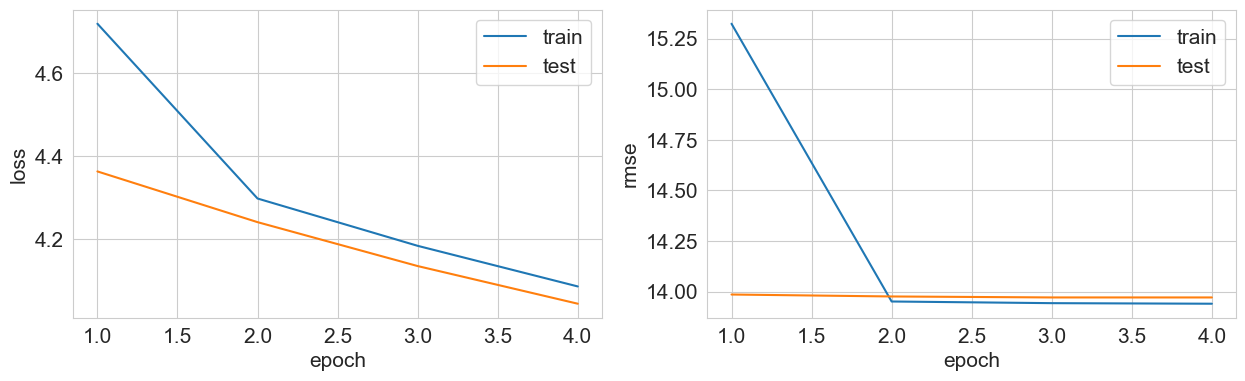

Epoch: 4, loss: 4.043902109958923, rmse: 13.971039772033691


([4.719526501370343, 4.297753892024221, 4.18360123444397, 4.085587698900711],
 [np.float32(15.323154),
  np.float32(13.95108),
  np.float32(13.942871),
  np.float32(13.940079)],
 [4.3631263446177195, 4.240719110416705, 4.134775197846331, 4.043902109958923],
 [np.float32(13.985543),
  np.float32(13.975913),
  np.float32(13.971086),
  np.float32(13.97104)])

In [44]:
train(fcnnc, optim_sgd, criterion, train_loader_enc, val_loader_enc, EPOCHS_fcnnc, encoder=encoder, wandb_project=None)

**Задание 3 (1 балл).** Прокомментируйте ваши наблюдения. Удалось ли побить бейзлайн? Как вы думаете, хорошая ли идея учить классификатор для этой задачи? Почему?

**Ответ:** побить бейзлайн не удалось, даже константное предсказание оказалось лучше нейросети. Учить классификатор идея не очень, так как при переходе к классам теряется информация о том, что года идут подрят, что есть более близкие. Допустим близость классов 1 и 2 как бы равна близости классов 1 и 40. Хотя в первом случае года близки, а во втором далеки. В постанвке задачи классификации модель не распознает это.


**Задание 4 (2 балла).** Теперь попробуем решать задачу как регрессию. Обучите нейронную сеть на MSE.

- Используйте такие же гиперпараметры обучения.
- Когда передаете целевую переменную в DataLoader, сделайте reshape в (-1, 1).
- Если что-то пойдет не так, можете попробовать меньшие значения `lr`.

In [46]:
class FCNNR(nn.Module):
  """fully connected neural network regression"""
  def __init__(self, in_features):
    super().__init__()
    self.model = nn.Sequential(
        nn.Linear(in_features, 128),
        nn.ReLU(),
        nn.Linear(128, 1)
    )

  def forward(self, x):
    return self.model(x)

In [47]:
# создадим dataloader'ы
train_dataset = TensorDataset(X_train, y_train.reshape(-1, 1))
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_dataset = TensorDataset(X_val, y_val.reshape(-1, 1))
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=True)
test_dataset = TensorDataset(X_test, y_test.reshape(-1, 1))
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=True)

In [48]:
LR_fcnnr = 1e-6
EPOCHS_fcnnr = 4

fcnnr = FCNNR(in_features).to(device)
optim_sgd_fcnnr = torch.optim.SGD(fcnnr.parameters(), lr=LR_fcnnr, momentum=0)
criterion_reg = nn.MSELoss()

wandb_fcnnr = {
  'project': 'dl-iad-hw-1',
  'name': 'fully connected neural network regression',
  'config': {
    'architecture': 'FCNNR',
    'learning_rate': LR_fcnnr,
    'scheduler': 'None',
    'epochs': EPOCHS_fcnnr,
    'optimizer': 'sgd'
  }
}

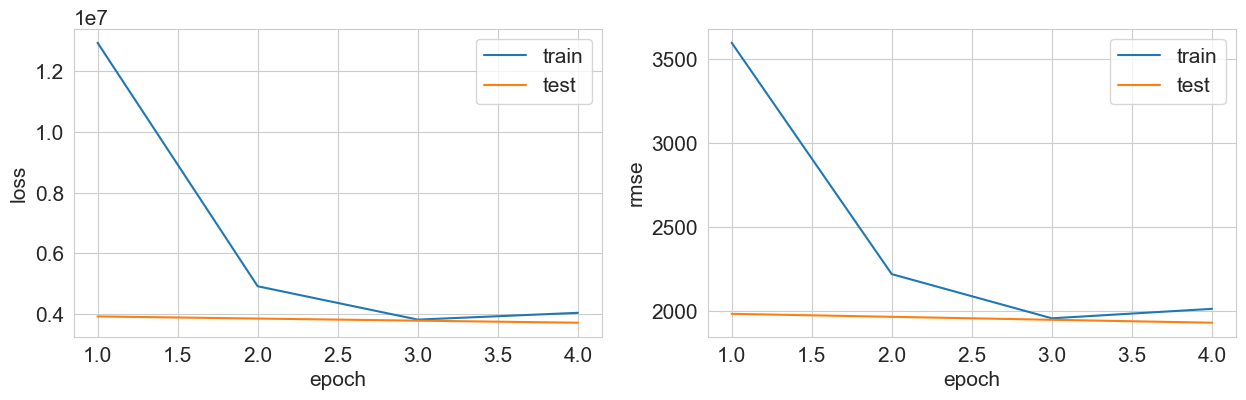

Epoch: 4, loss: 3718888.3341121012, rmse: 1928.4419447087591


([12934058.621649057, 4919057.43396342, 3821102.245342054, 4044786.511008828],
 [3596.3952260074334,
  2217.894820311238,
  1954.7639871201982,
  2011.1654608730798],
 [3925892.9458846906,
  3855848.930945802,
  3786609.7733759717,
  3718888.3341121012],
 [1981.3866220111336,
  1963.6315670068564,
  1945.9213173651117,
  1928.4419447087591])

In [49]:
train(fcnnr, optim_sgd_fcnnr, criterion_reg, train_loader, val_loader, EPOCHS_fcnnr, wandb_project=None)

**Задание 5 (1 балл).** Получилось ли у вас стабилизировать обучение? Помогли ли меньшие значения `lr`? Стало ли лучше от замены классификации на регрессию? Как вы думаете, почему так происходит? В качестве подсказки можете посмотреть на распределение целевой переменной и магнитуду значений признаков.

**Ответ:** стабилизировать обучение не удалось. От перехода к регрессии лучше не стало. Градиенты взрывались, но даже после решения этой проблемы, сильным уменьшением lr, наша модель не стала нормально обучаться, ошибка огромная. Это может происходиь так как целевая переменная сильно смещена - почти все песни, которые предоставленны, были написаны после 1990х годов. Так же сами признаки не отскалированны, что приводит к проблемам в обучении, так как их магнитуда сильно отличается.

**Задание 6 (1 балл).** Начнем с того, что попробуем отнормировать целевую переменную. Для этого воспользуемся min-max нормализацией, чтобы целевая переменная принимала значения от 0 до 1. Реализуйте функции `normalize` и `denormalize`, которые, соответственно, нормируют целевую переменную и применяют обратное преобразование. Минимум и максимум оцените по обучающей выборке (то есть эти константы должны быть фиксированными и не зависеть от передаваемой выборки).

In [50]:
MIN = torch.min(y_train)
DIFF = torch.max(y_train) - MIN
EPS = 1e-8 # будем использовать для вырожденного случая когда MAX - MIN будет меньше EPS и придется делить на число близкое к 0

def normalize(sample):
    """
    Min-max normalization to convert sample to [0, 1] range
    """
    if DIFF < EPS:
      return torch.zeros_like(sample)
    return (sample - MIN) / DIFF

def denormalize(sample):
    """
    Denormalize sample from [0, 1] to initial range
    """
    if DIFF < EPS:
      return torch.full_like(sample, MIN)
    return sample * DIFF + MIN

**Задание 7 (1 балл)** Теперь повторите эксперимент из **задания 4**, обучаясь на нормированной целевой переменной. Сделаем также еще одно изменение: добавим сигмоидную активацию после последнего линейного слоя сети. Таким образом мы гарантируем, что нейронная сеть предсказывает числа из промежутка $[0, 1]$. Использование активации - довольно распространенный прием, когда мы хотим получить числа из определенного диапазона значений.

In [51]:
y_train_scaled = normalize(y_train)
y_val_scaled = normalize(y_val)

In [55]:
# создадим dataloader'ы
train_dataset_ts = TensorDataset(X_train, y_train_scaled.reshape(-1, 1))
train_loader_ts = DataLoader(train_dataset_ts, batch_size=64, shuffle=True)
val_dataset_ts = TensorDataset(X_val, y_val_scaled.reshape(-1, 1))
val_loader_ts = DataLoader(val_dataset_ts, batch_size=64, shuffle=True)

In [56]:
class FCNNRTS(nn.Module):
  """fully connected neural network regression target scaled"""
  def __init__(self, in_features):
    super().__init__()
    self.model = nn.Sequential(
        nn.Linear(in_features, 128),
        nn.ReLU(),
        nn.Linear(128, 1),
        nn.Sigmoid()
    )

  def forward(self, x):
    return self.model(x)

In [57]:
LR_fcnnrts = 1e-4
EPOCHS_fcnnrts = 4

fcnnrts = FCNNRTS(in_features).to(device)
optim_sgd_fcnnrts = torch.optim.SGD(fcnnrts.parameters(), lr=LR_fcnnrts, momentum=0)
criterion_reg = nn.MSELoss()

wandb_fcnnrts = {
  'project': 'dl-iad-hw-1',
  'name': 'fully connected neural network regression target scaled',
  'config': {
    'architecture': 'FCNNRTS',
    'learning_rate': LR_fcnnrts,
    'scheduler': 'None',
    'epochs': EPOCHS_fcnnrts,
    'optimizer': 'sgd'
  }
}

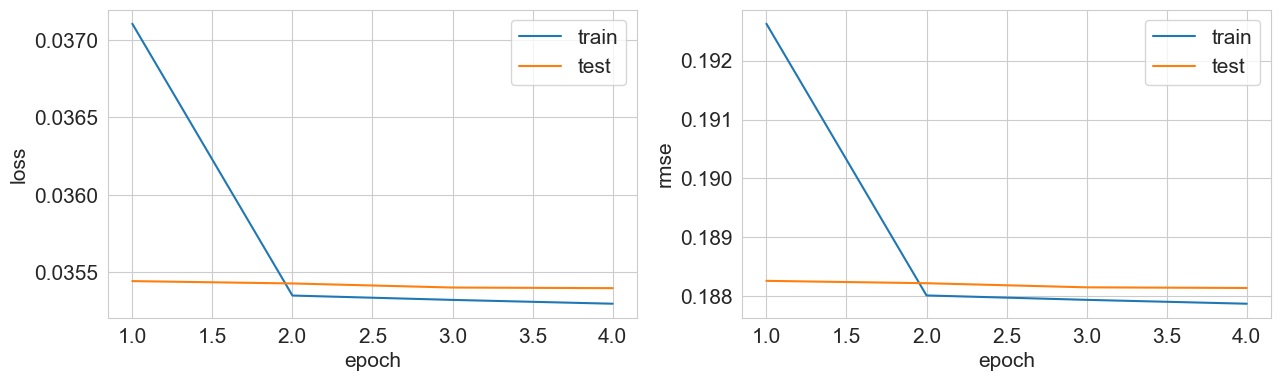

Epoch: 4, loss: 0.03539637430903764, rmse: 0.18813924181052086


In [58]:
_, _, _, rmses_val_fcnnrts = train(fcnnrts, optim_sgd_fcnnrts, criterion_reg, train_loader_ts, val_loader_ts, EPOCHS_fcnnrts, wandb_project=None)

In [59]:
print(f'RMSE (in years) on val for {wandb_fcnnrts['name']}: {denormalize(rmses_val_fcnnrts[-1]) - MIN}')

RMSE (in years) on val for fully connected neural network regression target scaled: 16.744384765625


**Задание 8 (2 балла).** На этот раз попробуем отнормировать не только целевую переменную, но и сами данные, которые подаются сети на вход. Для них будем использовать нормализацию через среднее и стандартное отклонение. Преобразуйте данные и повторите прошлый эксперимент. Скорее всего, имеет смысл увеличить число эпох обучения.

In [60]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)
X_train_scaled = torch.Tensor(X_train_scaled)
X_val_scaled = torch.Tensor(X_val_scaled)
X_test_scaled = torch.Tensor(X_test_scaled)

In [61]:
train_dataset_dts = TensorDataset(X_train_scaled, y_train_scaled.reshape(-1, 1))
train_loader_dts = DataLoader(train_dataset_dts, batch_size=64, shuffle=True)
val_dataset_dts = TensorDataset(X_val_scaled, y_val_scaled.reshape(-1, 1))
val_loader_dts = DataLoader(val_dataset_dts, batch_size=64, shuffle=True)
test_dataset_ds = TensorDataset(X_test_scaled, y_test.reshape(-1, 1))
test_loader_ds = DataLoader(test_dataset_ds, batch_size=64)

In [62]:
LR_fcnnrdts = 1e-3
EPOCHS_fcnnrdts = 15

fcnnrdts = FCNNRTS(in_features).to(device)
optim_sgd_fcnnrdts = torch.optim.SGD(fcnnrdts.parameters(), lr=LR_fcnnrdts, momentum=0)
criterion_reg = nn.MSELoss()

wandb_fcnnrdts = {
  'project': 'dl-iad-hw-1',
  'name': 'fully connected neural network regression data & target scaled',
  'config': {
    'architecture': 'FCNNRTS',
    'learning_rate': LR_fcnnrdts,
    'scheduler': 'None',
    'epochs': EPOCHS_fcnnrdts,
    'optimizer': 'sgd'
  }
}

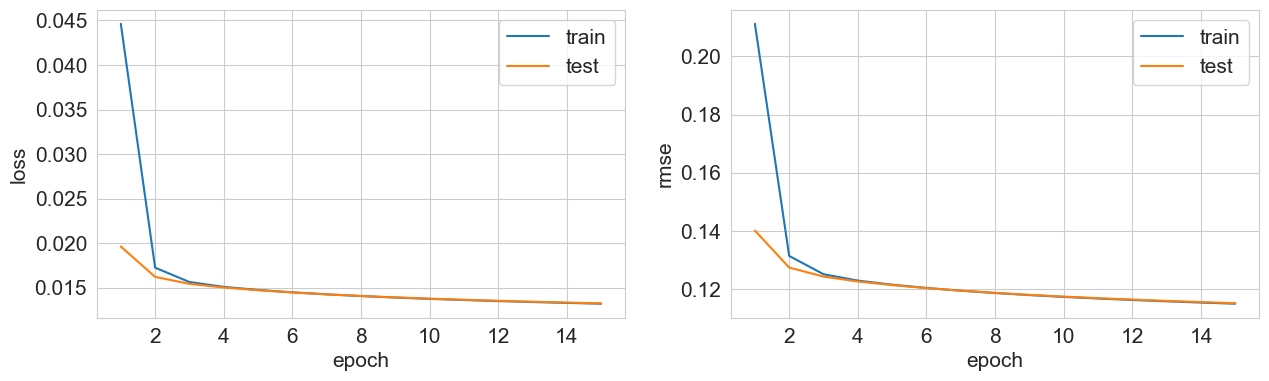

Epoch: 15, loss: 0.013238222532471498, rmse: 0.1150574749091579


In [63]:
_, _, _, rmses_val_fcnnrdts = train(fcnnrdts, optim_sgd_fcnnrdts, criterion_reg, train_loader_dts, val_loader_dts, EPOCHS_fcnnrdts, wandb_project=None)

In [64]:
print(f'RMSE (in years) on val for {wandb_fcnnrdts['name']}: {denormalize(rmses_val_fcnnrdts[-1]) - MIN}')

RMSE (in years) on val for fully connected neural network regression data & target scaled: 10.2401123046875


In [65]:
# посчитаем ошибку на тестовой выборке
fcnnrdts_predicts = predict(fcnnrdts, test_loader_ds, task='regression')
print(f'RMSE on test for {wandb_fcnnrdts['name']}: {rmse(denormalize(fcnnrdts_predicts), y_test)}')

RMSE on test for fully connected neural network regression data & target scaled: 10.101383209228516


Если вы все сделали правильно, то у вас должно было получиться качество, сравнимое с `Ridge` регрессией.

**Мораль:** как видите, нам пришлось сделать очень много хитрых телодвижений, чтобы нейронная сеть работала хотя бы так же, как и простая линейная модель. Здесь, конечно, показан совсем экстремальный случай, когда без нормализации данных нейронная сеть просто не учится. Как правило, в реальности завести нейронную сеть из коробки не очень сложно, но вот заставить ее работать на полную &mdash; куда более трудоемкая задача. Написание пайплайнов обучения нейросетевых моделей требует большой аккуратности, а дебаг часто превращается в угадайку. К счастью, очень часто на помощь приходит интуиция, и мы надеемся, что вы сможете выработать ее в течение нашего курса. Начнем с двух советов, которые стоит принять на вооружение:

- Обязательно начинаем любые эксперименты с бейзлайнов: без них мы бы не поняли, что нейронная сеть не учится в принципе.
- При постановке эксперментов старайтесь делать минимальное количество изменений за раз (в идеале одно!): только так можно понять, какие конкретно изменения влияют на результат.

## Часть III. Улучшаем нейронную сеть (максимум 10 баллов)

Продолжим экспериментировать с нейронной сетью, чтобы добиться еще лучшего качества.

**Задание 9 (1 балл).** Давайте попробуем другие оптимизаторы. Обучите нейросеть с помощью SGD+momentum и Adam. Опишите свои наблюдения и в дальнейших запусках используйте лучший оптимизатор. Для Adam обычно берут learning rate поменьше, в районе $10^{-3}$.

In [66]:
LR_fcnnrm = 1e-3
EPOCHS_fcnnrm = 10

fcnnrm = FCNNRTS(in_features).to(device)
optim_sgd_fcnnrm = torch.optim.SGD(fcnnrm.parameters(), lr=LR_fcnnrm, momentum=0.9)
criterion_reg = nn.MSELoss()

wandb_fcnnrm = {
  'project': 'dl-iad-hw-1',
  'name': 'FC NN REG data & target scaled + momentum',
  'config': {
    'architecture': 'FCNNRTS',
    'learning_rate': LR_fcnnrm,
    'scheduler': 'None',
    'epochs': EPOCHS_fcnnrm,
    'optimizer': 'sgd+momentum'
  }
}

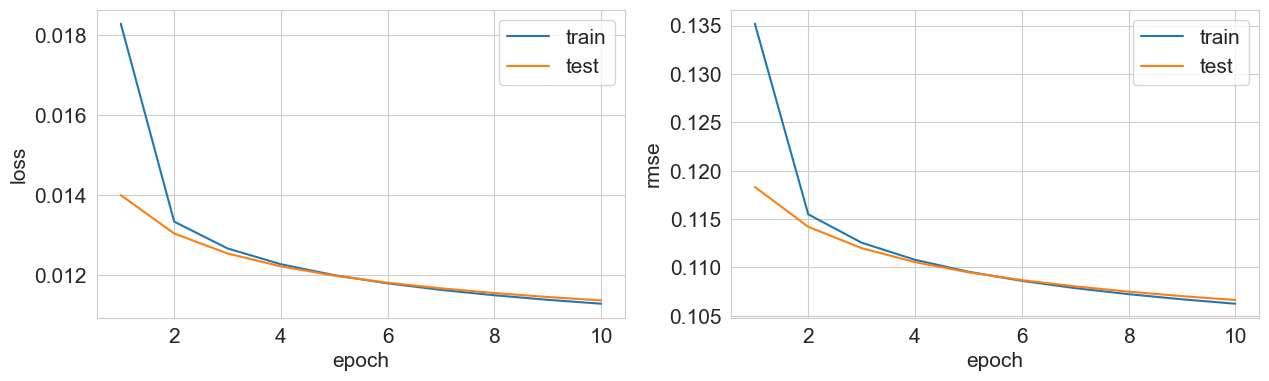

Epoch: 10, loss: 0.011369981520510261, rmse: 0.10663011544826471


In [67]:
_, _, _, rmses_val_fcnnrm = train(fcnnrm, optim_sgd_fcnnrm, criterion_reg, train_loader_dts, val_loader_dts, EPOCHS_fcnnrm, wandb_project=None)

In [68]:
print(f'RMSE (in years) on val for {wandb_fcnnrm['name']}: {denormalize(rmses_val_fcnnrm[-1]) - MIN}')

RMSE (in years) on val for FC NN REG data & target scaled + momentum: 9.4901123046875


In [69]:
LR_fcnnra = 1e-3
EPOCHS_fcnnra = 10

fcnnra = FCNNRTS(in_features).to(device)
optim_sgd_fcnnra = torch.optim.Adam(fcnnra.parameters(), lr=LR_fcnnra)
criterion_reg = nn.MSELoss()

wandb_fcnnra = {
  'project': 'dl-iad-hw-1',
  'name': 'FC NN REG data & target scaled + Adam',
  'config': {
    'architecture': 'FCNNRTS',
    'learning_rate': LR_fcnnra,
    'scheduler': 'None',
    'epochs': EPOCHS_fcnnra,
    'optimizer': 'Adma'
  }
}

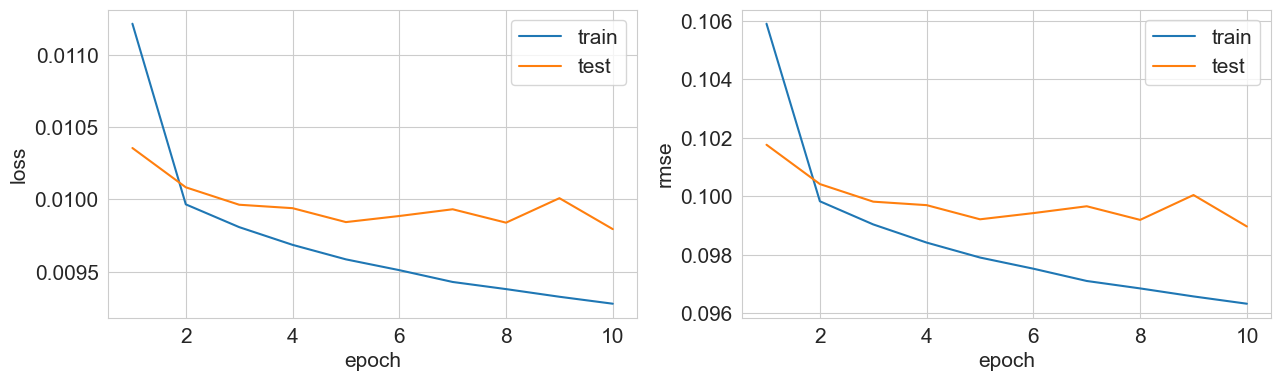

Epoch: 10, loss: 0.009794552090333652, rmse: 0.09896742944188079


In [70]:
_, _, _, rmses_val_fcnnra = train(fcnnra, optim_sgd_fcnnra, criterion_reg, train_loader_dts, val_loader_dts, EPOCHS_fcnnra, wandb_project=None)

In [71]:
print(f'RMSE (in years) on val for {wandb_fcnnra['name']}: {denormalize(rmses_val_fcnnra[-1]) - MIN}')

RMSE (in years) on val for FC NN REG data & target scaled + Adam: 8.80810546875


__Ваше подробное описание:__ во-первых оба оптимизатора дают лучшие результаты чем просто SGD. При использовании Adam заметно переобучение. При использование SGD+momentum ошибка на валидации (на графиках test) и обучении такая же. С momentum'ом ошибка на валидационной выборке падает также, как и на выборке для обучения, а вот для Adam кривая ошибки на валидации лежит выше и она менее гладкая. В итоге получаем, что SGD+momentum выглядит стабильнее, но ошибка на валидации меньше в итоге при использовании Adam.

**Задание 10 (1 балл).** Теперь сделаем нашу нейронную сеть более сложной. Попробуйте сделать сеть:

- более широкой (то есть увеличить размерность скрытого слоя, например, вдвое)
- более глубокой (то есть добавить еще один скрытый слой)

In [72]:
class FCNNRN(nn.Module):
  """fully connected neural network regression new architecture"""
  def __init__(self, in_features):
    super().__init__()
    self.model = nn.Sequential(
        nn.Linear(in_features, 256),
        nn.ReLU(),
        nn.Linear(256, 128),
        nn.ReLU(),
        nn.Linear(128, 1),
        nn.Sigmoid()
    )

  def forward(self, x):
    return self.model(x)

In [73]:
LR_fcnnrn = 1e-3
EPOCHS_fcnnrn = 10

fcnnrn = FCNNRN(in_features).to(device)
optim_sgd_fcnnrn = torch.optim.Adam(fcnnrn.parameters(), lr=LR_fcnnrn)
criterion_reg = nn.MSELoss()

wandb_fcnnrn = {
  'project': 'dl-iad-hw-1',
  'name': 'FC NN REG extended; data & target scaled + Adam',
  'config': {
    'architecture': 'FCNNRN',
    'learning_rate': LR_fcnnrn,
    'scheduler': 'None',
    'epochs': EPOCHS_fcnnrn,
    'optimizer': 'Adam'
  }
}

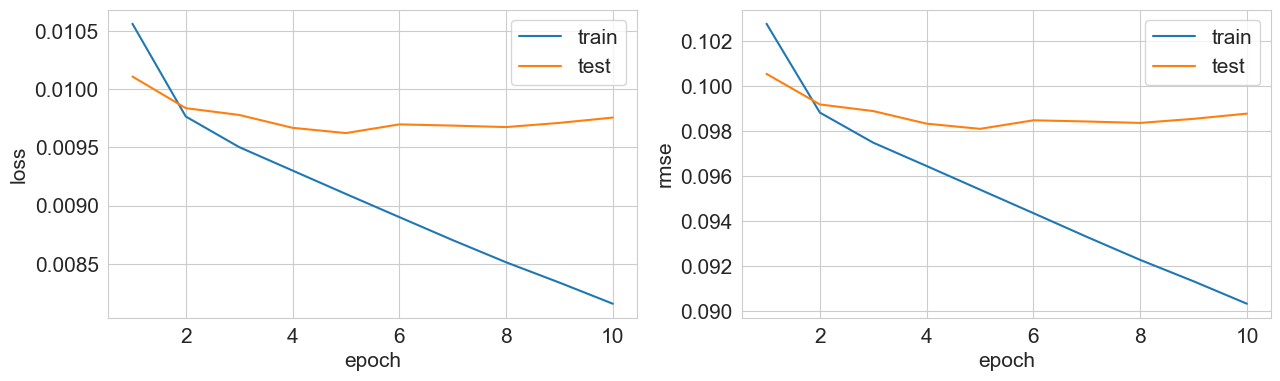

Epoch: 10, loss: 0.00975670296673431, rmse: 0.09877602425049466


In [74]:
_, _, _, rmses_val_fcnnrn = train(fcnnrn, optim_sgd_fcnnrn, criterion_reg, train_loader_dts, val_loader_dts, EPOCHS_fcnnrn, wandb_project=None)

In [75]:
print(f'RMSE (in years) on val for {wandb_fcnnrn['name']}: {denormalize(rmses_val_fcnnrn[-1]) - MIN}')

RMSE (in years) on val for FC NN REG extended; data & target scaled + Adam: 8.791015625


Опишите, как увеличение числа параметров модели влияет на качество на обучающей и валидационной выборках (без их описания за работу ставится ноль баллов)

__Ваше подробное описание:__ теперь стало видно, что модель больше переобучается (кривая ошибки на валидации лежит выше кривой ошибки на обучении, чем раньше), это логично, ведь модель стала больше, и она может запомнить закономерность в тренировачной выборке лучше, чем более простая модель.

**Задание 11 (1 балл).** Как вы должны были заметить, более сложная модель стала сильнее переобучаться. Попробуем разные методы регуляризации, чтобы бороться с переобучением. Проведите два эксперимента:

- Добавьте слой дропаута с параметром $p=0.2$ после каждого линейного слоя, кроме последнего.
- Попробуйте batch-нормализацию вместо дропаута. Строго говоря, batch-нормализация не является методом регуляризации, но никто не запрещает нам экспериментировать с ней.

In [76]:
class FCNNRD(nn.Module):
  """fully connected neural network regression new architecture with dropout"""
  def __init__(self, in_features):
    super().__init__()
    self.model = nn.Sequential(
        nn.Linear(in_features, 256),
        nn.ReLU(),
        nn.Dropout(0.2),
        nn.Linear(256, 128),
        nn.ReLU(),
        nn.Dropout(0.2),
        nn.Linear(128, 1),
        nn.Sigmoid()
    )

  def forward(self, x):
    return self.model(x)

In [77]:
LR_fcnnrd = 1e-3
EPOCHS_fcnnrd = 10

fcnnrd = FCNNRD(in_features).to(device)
optim_sgd_fcnnrd = torch.optim.Adam(fcnnrd.parameters(), lr=LR_fcnnrd)
criterion_reg = nn.MSELoss()

wandb_fcnnrd = {
  'project': 'dl-iad-hw-1',
  'name': 'FC NN REG extended; data & target scaled + Adam',
  'config': {
    'architecture': 'FCNNRD',
    'learning_rate': LR_fcnnrd,
    'scheduler': 'None',
    'epochs': EPOCHS_fcnnrd,
    'optimizer': 'Adam'
  }
}

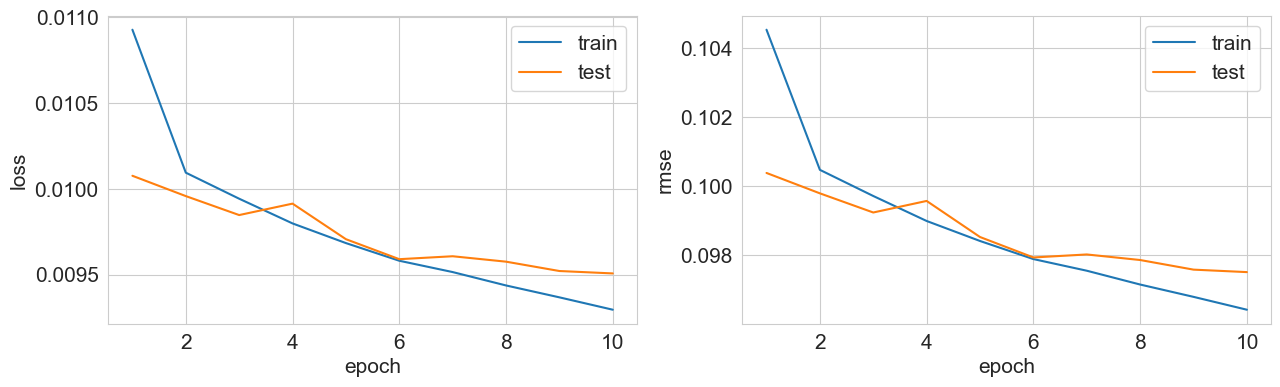

Epoch: 10, loss: 0.00950718466460815, rmse: 0.09750479303402551


In [78]:
_, _, _, rmses_val_fcnnrd = train(fcnnrd, optim_sgd_fcnnrd, criterion_reg, train_loader_dts, val_loader_dts, EPOCHS_fcnnrd, wandb_project=None)

In [79]:
print(f'RMSE (in years) on val for {wandb_fcnnrd['name']}: {denormalize(rmses_val_fcnnrd[-1]) - MIN}')

RMSE (in years) on val for FC NN REG extended; data & target scaled + Adam: 8.677978515625


Теперь попробуем BatchNorm

In [81]:
class FCNNRB(nn.Module):
  """fully connected neural network regression new architecture with BatchNorm"""
  def __init__(self, in_features):
    super().__init__()
    self.model = nn.Sequential(
        nn.Linear(in_features, 256),
        nn.BatchNorm1d(256),
        nn.ReLU(),
        nn.Linear(256, 128),
        nn.BatchNorm1d(128),
        nn.ReLU(),
        nn.Linear(128, 1),
        nn.Sigmoid()
    )

  def forward(self, x):
    return self.model(x)

In [82]:
LR_fcnnrb = 1e-3
EPOCHS_fcnnrb = 10

fcnnrb = FCNNRB(in_features).to(device)
optim_sgd_fcnnrb = torch.optim.Adam(fcnnrb.parameters(), lr=LR_fcnnrb)
criterion_reg = nn.MSELoss()

wandb_fcnnrb = {
  'project': 'dl-iad-hw-1',
  'name': 'FC NN REG extended; data & target scaled + Adam + BatchNorm',
  'config': {
    'architecture': 'FCNNRB',
    'learning_rate': LR_fcnnrb,
    'scheduler': 'None',
    'epochs': EPOCHS_fcnnrb,
    'optimizer': 'Adam'
  }
}

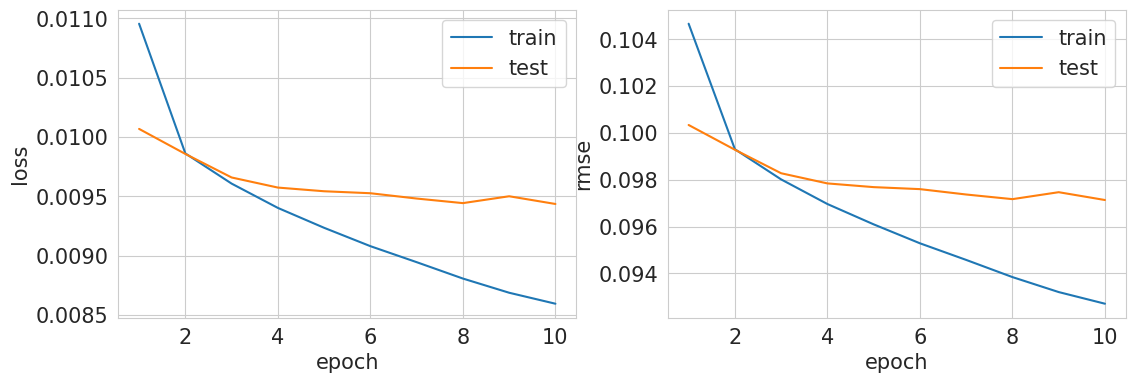

Epoch: 10, loss: 0.009435295005571233, rmse: 0.09713544669980796


In [ ]:
_, _, _, rmses_val_fcnnrb = train(fcnnrb, optim_sgd_fcnnrb, criterion_reg, train_loader_dts, val_loader_dts, EPOCHS_fcnnrb, wandb_project=None)

In [ ]:
print(f'RMSE (in years) on val for {wandb_fcnnrb['name']}: {denormalize(rmses_val_fcnnrb[-1]) - MIN}')

RMSE (in years) on val for FC NN REG extended; data & target scaled + Adam + BatchNorm: 8.64501953125


Опишите результаты экспериментов (без их описания за работу ставится ноль баллов)

__Ваше подробное описание:__ меньшее переобучение получили с Dropout - графики ошибок идут почти вровень. Но ошибка в итоге меньше при BatchNorm. Также при использовании BatchNorm видно, что графики более гладкие и обучение идет плавнее.

**Задание 12 (1 балл).** Теперь, когда мы определились с выбором архитектуры нейронной сети, пора заняться рутиной DL-инженера &mdash; перебором гиперпараметров. Подберите оптимальное значение lr по значению RMSE на валидации (по логарифмической сетке, достаточно посмотреть 3-4 значения). Затем подберите оптимальное значение weight decay для данного lr (тоже по логарифмической сетке, типичные значения этого параметра лежат в диапазоне $[10^{-6}, 10^{-3}]$, но не забудьте включить нулевое значение в сетку). Постройте графики зависимости RMSE на трейне и на валидации от значений параметров. Прокомментируйте получившиеся зависимости.

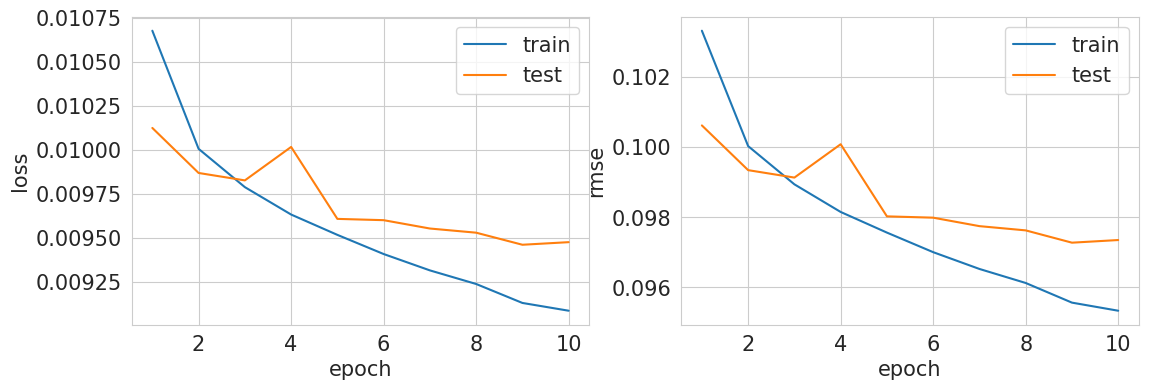

Epoch: 10, loss: 0.009477896553599258, rmse: 0.09735448912915756


In [ ]:
lr_list = np.logspace(-5,-2,4)
EPOCHS = 10
criterion_reg = nn.MSELoss()
rmses_train = []
rmses_val = []
best_rmse = np.inf
best_lr = None

for lr in lr_list:
  fcnnrb = FCNNRB(in_features).to(device)
  optim_sgd = torch.optim.Adam(fcnnrb.parameters(), lr=lr)

  wandb_fcnnrb = {
    'project': 'dl-iad-hw-1',
    'name': f'FC NN REG final with lr: {lr}',
    'config': {
      'architecture': 'FCNNRB',
      'learning_rate': lr,
      'scheduler': 'None',
      'epochs': EPOCHS,
      'optimizer': 'Adam'
    }
  }

  _, rmse_train, _, rmse_val = train(fcnnrb, optim_sgd, criterion_reg, train_loader_dts, val_loader_dts, EPOCHS, wandb_project=None)
  rmses_train.append(rmse_train[-1])
  rmses_val.append(rmse_val[-1])

  if best_lr is None or rmse_val[-1] < best_rmse:
    best_lr = lr
    best_rmse = rmse_val[-1]

In [46]:
def plot_rmse_param_graph(param_name, params, best_param, best_rmse, rmses_train, rmses_val):
    fig, axs = plt.subplots(1, 2, figsize=(15, 4))
    plt.suptitle(f'best rmse={best_rmse} on best {param_name}={best_param}')
    axs[0].plot(params, rmses_train)
    axs[0].set_ylabel('rmse on train')

    axs[1].plot(params, rmses_val)
    axs[1].set_ylabel('rmse on validation')

    for ax in axs:
        ax.set_xlabel(param_name)

    plt.show()

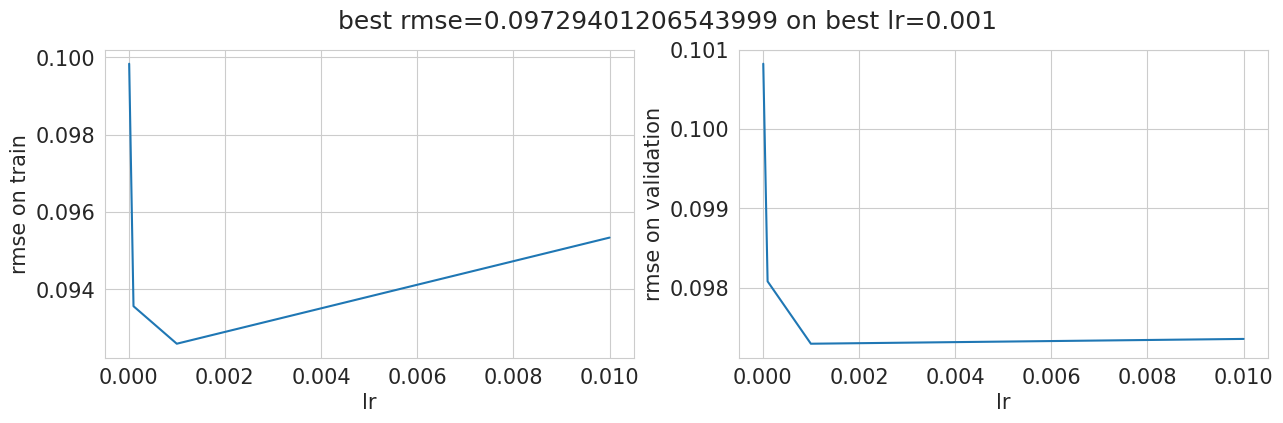

In [47]:
plot_rmse_param_graph('lr', lr_list, best_lr, best_rmse, rmses_train, rmses_val)

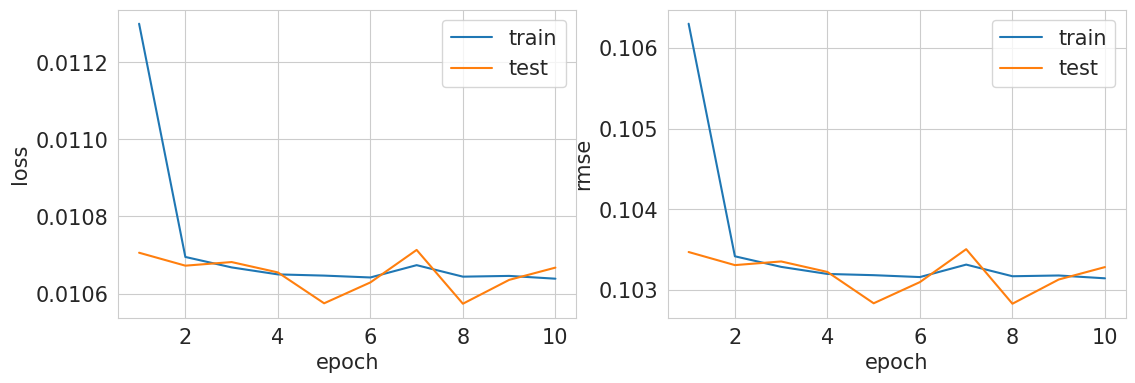

Epoch: 10, loss: 0.010667238316274807, rmse: 0.1032823233485518


In [56]:
weight_decay_list = np.logspace(-6,-3,3)
weight_decay_list = np.concatenate(([0], weight_decay_list))
rmses_train = []
rmses_val = []
best_rmse = np.inf
best_wd = None

for wd in weight_decay_list:
  fcnnrb = FCNNRB(in_features).to(device)
  optim_sgd = torch.optim.Adam(fcnnrb.parameters(), lr=best_lr, weight_decay=wd)

  wandb_fcnnrb = {
    'project': 'dl-iad-hw-1',
    'name': f'FC NN REG final with wd: {wd}',
    'config': {
      'architecture': 'FCNNRB',
      'learning_rate': best_lr,
      'weight_decay': wd,
      'scheduler': 'None',
      'epochs': EPOCHS,
      'optimizer': 'Adam'
    }
  }

  _, rmse_train, _, rmse_val = train(fcnnrb, optim_sgd, criterion_reg, train_loader_dts, val_loader_dts, EPOCHS, wandb_project=wandb_fcnnrb)
  rmses_train.append(rmse_train[-1])
  rmses_val.append(rmse_val[-1])

  if best_wd is None or rmse_val[-1] < best_rmse:
    best_wd = wd
    best_rmse = rmse_val[-1]

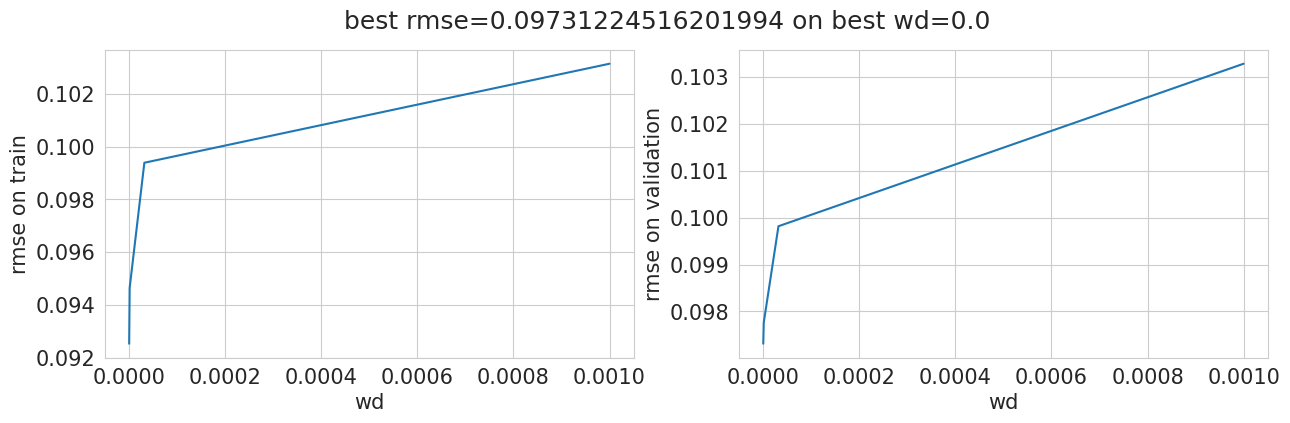

In [57]:
plot_rmse_param_graph('wd', weight_decay_list, best_wd, best_rmse, rmses_train, rmses_val)

In [58]:
print(f'RMSE (in years) on val: {denormalize(best_rmse) - MIN}')

RMSE (in years) on val: 8.6607666015625


Опишите результаты экспериментов (без их описания за работу ставится ноль баллов)

__Ваше подробное описание:__ при нахождении лучшего lr было видно, что при lr=0.001 у нашей модели наилучшие значения. При маленьком lr модель обучалась слишком медленно, а при больших lr обучение модели стало сложнее, так как при омтимизации было сложнее попасть в точки минимума, он их стал перескакивать.  

> Как вы могли заметить, еще одна рутина DL-инженера &mdash; утомительное ожидание обучения моделей.




**Задание 13 (6 баллов).**

Думаю направление размышлений вы поняли. Постарайтесь с помощью своих экспериментов выбить максимально возможное значение RMSE на тестовой выборке. Соотношение между полученным значением метрики на тестовой выборке и баллами за задание следующее:

- $\text{RMSE} \le 8.90 $ &mdash; 2 балла
- $\text{RMSE} \le 8.80 $ &mdash; 4 балла
- $\text{RMSE} \le 8.75 $ &mdash; 6 баллов

**Различные трюки, которые можно попробовать:**

1. Попробуйте делать во время обучения раннюю остановку обучения и сохранять модель в тот момент, когда качество на валидации начало ухудшаься, то есть модель начала переобучаться
2. Попробуйте усложнить архитектуру нейросет
    - Больше/меньше нейронов
    - Больше/меньше слоёв
    - Другие функции активации (tanh, relu, leaky relu, elu etc)
    - Регуляризация (dropout, l1,l2)
3. Попробуйте другие оптимизаторы, а также смену скорости обучения по расписанию.

И это далеко не полный список. Обратите внимание, что делать grid_search для больших сеток это довольно времязатратное занятие... Попробовать несколько значений, как мы делали в заданиях выше, адекватно, но делать какой-то огромный перебор будет самоубийством.

Логгируйте свои эксперименты. За один прогон пробуйте одно изменение. Иначе будет непонятно какие именно изменения улучшили качество, а какие ухудшили.

In [38]:
# сначала посмотрим какое сейчас у нас качество на test при текущей лучшей архитектуре, но сначала нам придется эту архитектуру обучить
EPOCHS = 10

model_1 = FCNNRB(in_features).to(device)
optim_sgd_model_1 = torch.optim.Adam(model_1.parameters(), lr=best_lr, weight_decay=best_wd)
criterion_reg = nn.MSELoss()

wandb_model_1 = {
  'project': 'dl-iad-hw-1',
  'name': 'model 1',
  'config': {
    'architecture': 'FCNNRB',
    'learning_rate': best_lr,
    'weight_decay': best_wd,
    'scheduler': 'None',
    'epochs': EPOCHS,
    'optimizer': 'Adam'
  }
}

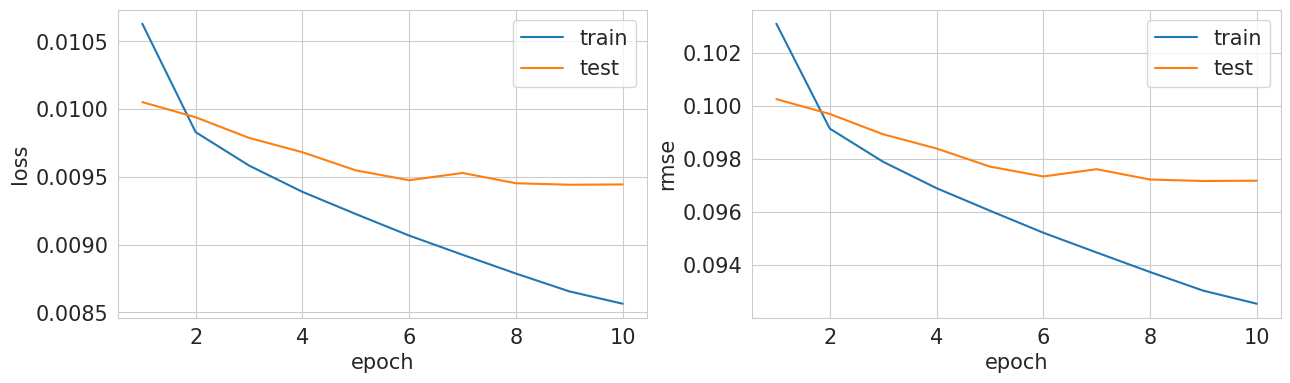

Epoch: 10, loss: 0.009444171933558015, rmse: 0.09718112951369734


In [40]:
_, _, _, rmses_val_model_1 = train(model_1, optim_sgd_model_1, criterion_reg, train_loader_dts, val_loader_dts, EPOCHS, wandb_project=wandb_model_1)

In [41]:
print(f'RMSE (in years) on val for {wandb_model_1['name']}: {denormalize(rmses_val_model_1[-1]) - MIN}')

RMSE (in years) on val for model 1: 8.649169921875


In [42]:
# посчитаем ошибку на тестовой выборке
model_1_predicts = predict(model_1, test_loader_ds, task='regression')
print(f'RMSE on test for {wandb_model_1['name']}: {rmse(denormalize(model_1_predicts), y_test)}')

RMSE on test for model 1: 8.740683555603027


Нужного качества на тесте мы уже достигли, но ради интереса попробуем его еще улучшить.

Попробуем изменить функции активации на гиперболический тангенс.

In [43]:
class FCNNRT(nn.Module):
  """fully connected neural network regression new architecture with BatchNorm and tanh"""
  def __init__(self, in_features):
    super().__init__()
    self.model = nn.Sequential(
        nn.Linear(in_features, 256),
        nn.BatchNorm1d(256),
        nn.Tanh(),
        nn.Linear(256, 128),
        nn.BatchNorm1d(128),
        nn.Tanh(),
        nn.Linear(128, 1),
        nn.Sigmoid()
    )

  def forward(self, x):
    return self.model(x)

In [45]:
EPOCHS = 10

model_2 = FCNNRT(in_features).to(device)
optim_sgd_model_2 = torch.optim.Adam(model_2.parameters(), lr=best_lr, weight_decay=best_wd)
criterion_reg = nn.MSELoss()

wandb_model_2 = {
  'project': 'dl-iad-hw-1',
  'name': 'model 2',
  'config': {
    'architecture': 'FCNNRT',
    'learning_rate': best_lr,
    'weight_decay': best_wd,
    'scheduler': 'None',
    'epochs': EPOCHS,
    'optimizer': 'Adam'
  }
}

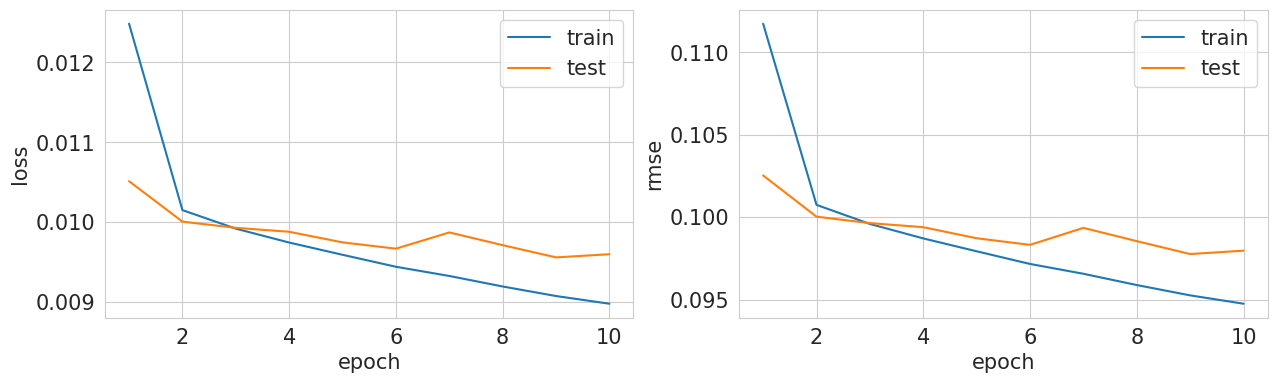

Epoch: 10, loss: 0.009597107000635945, rmse: 0.09796482532335749


In [46]:
_, _, _, rmses_val_model_2 = train(model_2, optim_sgd_model_2, criterion_reg, train_loader_dts, val_loader_dts, EPOCHS, wandb_project=wandb_model_2)

In [47]:
print(f'RMSE (in years) on val for {wandb_model_2['name']}: {denormalize(rmses_val_model_2[-1]) - MIN}')

RMSE (in years) on val for model 2: 8.7188720703125


ну и посчитаем ошибку на тесте

In [54]:
# посчитаем ошибку на тестовой выборке
model_2_predicts = predict(model_2, test_loader_ds, task='regression')
print(f'RMSE on test for {wandb_model_2['name']}: {rmse(denormalize(model_2_predicts), y_test)}')

RMSE on test for model 3: 8.76888370513916


Качество на валидации (да и на тесте) немного хуже, но в тоже время заменто, что модель меньше переобучилась так как графики ошибок на трейне и валидации ближе, чем при ReLU.

Еще давайте попробуем увеличить сеть, добавив еще слой.

In [50]:
class FCNNRDV(nn.Module):
  """fully connected neural network regression new architecture with BatchNorm. Deeper version."""
  def __init__(self, in_features):
    super().__init__()
    self.model = nn.Sequential(
        nn.Linear(in_features, 256),
        nn.BatchNorm1d(256),
        nn.ReLU(),
        nn.Linear(256, 128),
        nn.BatchNorm1d(128),
        nn.ReLU(),
        nn.Linear(128, 64),
        nn.BatchNorm1d(64),
        nn.ReLU(),
        nn.Linear(64, 1),
        nn.Sigmoid()
    )

  def forward(self, x):
    return self.model(x)

In [53]:
EPOCHS = 10

model_3 = FCNNRDV(in_features).to(device)
optim_sgd_model_3 = torch.optim.Adam(model_3.parameters(), lr=best_lr, weight_decay=best_wd)
criterion_reg = nn.MSELoss()

wandb_model_3 = {
  'project': 'dl-iad-hw-1',
  'name': 'model 3',
  'config': {
    'architecture': 'FCNNRDV',
    'learning_rate': best_lr,
    'weight_decay': best_wd,
    'scheduler': 'None',
    'epochs': EPOCHS,
    'optimizer': 'Adam'
  }
}

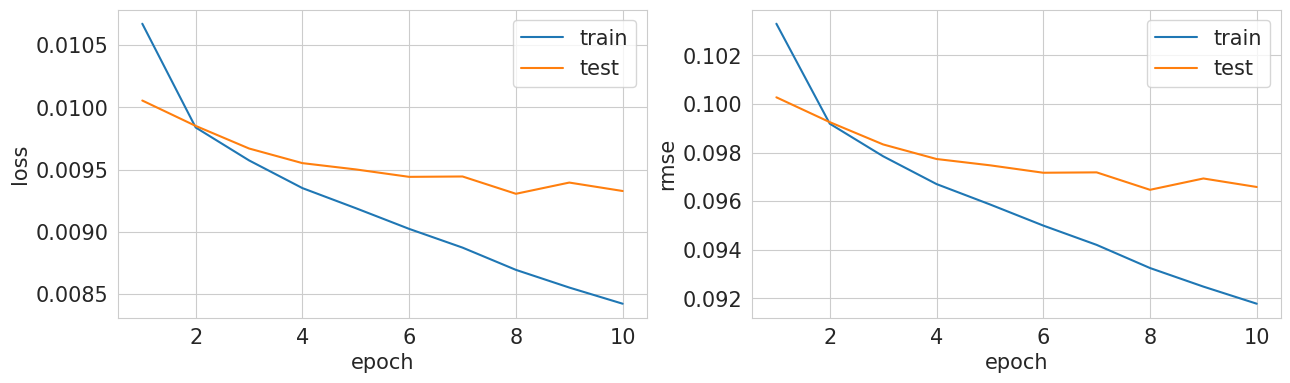

Epoch: 10, loss: 0.00932848864617076, rmse: 0.09658410141514369


In [55]:
_, _, _, rmses_val_model_3 = train(model_3, optim_sgd_model_3, criterion_reg, train_loader_dts, val_loader_dts, EPOCHS, wandb_project=wandb_model_3)

In [56]:
print(f'RMSE (in years) on val for {wandb_model_3['name']}: {denormalize(rmses_val_model_3[-1]) - MIN}')

RMSE (in years) on val for model 3: 8.595947265625


In [57]:
# посчитаем ошибку на тестовой выборке
model_3_predicts = predict(model_3, test_loader_ds, task='regression')
print(f'RMSE on test for {wandb_model_3['name']}: {rmse(denormalize(model_3_predicts), y_test)}')

RMSE on test for model 3: 8.732549667358398


Стало чуть лучше чем первая модель, особенно на валидации и трейне. Это логично - сеть стала больше и может запомнить более сложные закономерности.

Опишите результаты экспериментов (без их описания за работу ставится ноль баллов)

__Ваше подробное описание:__ описание по экспериментам под каждым из них. Лучше всех себя показал третий.